In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import math
import mpmath as mp


# Code to calculate the mean of the Sackin index

In [2]:
# Reference formulas (Yule, uniform, max, min)

# Yule mean
def sackin_yule(n):
    return 2 * n * np.sum(1 / np.arange(2, n + 1))

# Maximum value
def max_sackin(n):
    return (n * (n + 1)) / 2 - 1

# Minimum value
def min_sackin(n):
    return math.floor(np.log2(n) - 1)*n + 3*n - 2**(math.floor(np.log2(n) - 1) + 2)


# Uniform model
def sackin_uniform(n):
    return n * (np.prod(np.arange(2*n - 2, 1, -2) / np.arange(2*n - 3, 0, -2)) - 1)

In [3]:
# Calculating the mean of the Sackin index under the biased speciation model using high-precision arithmetic
# Default precision: max(40, n/2) digits (we found it to be stable for n up to about 10000)

# Returns the ej probabilities for constant p model as an array of length n-2
def constant_p_ej_stable(n, p):
    mp.mp.dps = max(40, n // 2)  # set decimal places
    return [mp.mpf(mp.mpf(p)**j + (mp.mpf(1 - p))**j - 1) for j in range(2, n-1)]

# Return the k-th moment of beta(a,b) distribution with high-precision arithmetic
def beta_moment_stable(a, b, k, digits):
    mp.mp.dps = digits
    return mp.gamma(mp.mpf(a) + k) * mp.gamma(mp.mpf(a) + mp.mpf(b)) / (mp.gamma(mp.mpf(a)) * mp.gamma(mp.mpf(a) + mp.mpf(b) + k))

# Return the ej probabilities for beta(a,b) model as an array of length n-2
def beta_ej_stable(n, a, b):
    mp.mp.dps = max(40, n // 2)  # set decimal places

    ej = []
    for k in range(2, n-1):
        beta_moment_a = beta_moment_stable(a, b, k, mp.mp.dps)
        beta_moment_b = beta_moment_stable(b, a, k, mp.mp.dps)
        ej.append(beta_moment_a + beta_moment_b - mp.mpf(1))
    return ej

# Sum method with high-precision arithmetic
def sackin_mean_sum_stable(n, ej):
    # Corner case: n < 3
    if n < 3:
        return max_sackin(n)
    
    mp.mp.dps = max(40, n//2) # set decimal places
    
    total = mp.mpf((n*(n+1)) / 2 - 1)
    current = mp.mpf((n - 1) * (n - 2) / 2)
    for k in range(3, n):
        current *= mp.mpf(ej[k - 3]) * mp.mpf(int(n - k)) / mp.mpf(k)
        total += current
    return total

# Constant p mean
def sackin_mean_const_p(n, p):
    return sackin_mean_sum_stable(n, constant_p_ej_stable(n, p))

# Beta mean
def sackin_mean_beta(n, a, b):
    return sackin_mean_sum_stable(n, beta_ej_stable(n, a, b))


# Plotting the results

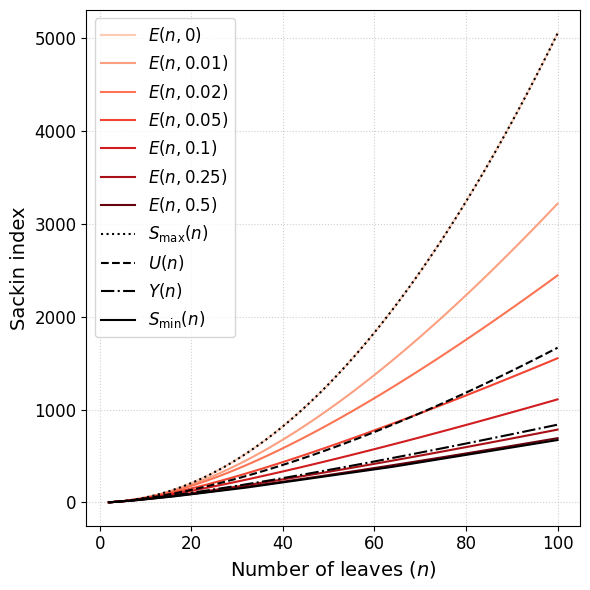

In [4]:
plt.figure(figsize=(6,6))

# Data range
N = range(2, 100 + 1)




# Values of p to plot
p = [0, 0.01, 0.02, 0.05, 0.1, 0.25, 0.5]

# Use a colormap for probabilities, using shades of a single color
# what is best colormap? 
min_color = 0.2
max_color = 1.0
colors = cm.Reds(np.linspace(min_color, max_color, len(p)))

for prob, color in zip(p, colors):
    means = [sackin_mean_const_p(n, prob) for n in N]
    plt.plot(N, means, label=f"$E(n,{prob})$", alpha=1, color=color, lw=1.5)

# Add reference models
plt.plot(N, [max_sackin(n) for n in N], 
         label="$S_{\\max} (n)$", linestyle=':', color='black', alpha=1, linewidth=1.5)
plt.plot(N, [sackin_uniform(n) for n in N], 
         label="$U(n)$", linestyle='--', color='black', alpha=1, linewidth=1.5)
plt.plot(N, [sackin_yule(n) for n in N], 
         label="$Y(n)$", linestyle='-.', color='black', alpha=1, linewidth=1.5)
plt.plot(N, [min_sackin(n) for n in N], 
         label="$S_{\\min}(n)$", linestyle='-', color='black', alpha=1, linewidth=1.5)

# Labels and title
plt.xlabel("Number of leaves ($n$)", fontsize=14)
plt.ylabel("Sackin index", fontsize=14)
# plt.title(r"Mean Sackin index under biased speciation model with split distribution $\lambda \sim p$", fontsize=16)

# Fontsize of axis ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


# Legend only for reference lines
plt.legend(fontsize=12, loc="upper left")

# Grid and layout
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

# Save and show
plt.savefig("./plots/sackin_biased_speciation_constant_p.png", dpi=300)
plt.show()

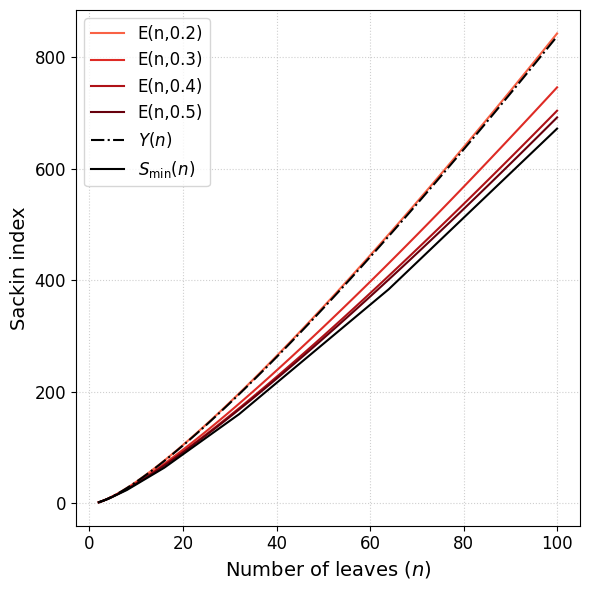

In [5]:
# N = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]

yule = [sackin_yule(n) for n in N]
# p05 = [sackin_mean_const_p(n, 0.5) for n in N]
minimum = [min_sackin(n) for n in N]

plt.figure(figsize=(6,6))


p = [0.2, 0.3, 0.4, 0.5]
for prob in p:
     means = [sackin_mean_const_p(n, prob) for n in N]
     plt.plot(N, means, label=f"E(n,{prob})", linestyle='-', alpha=1, color = cm.Reds((max_color - min_color) / 0.5 * prob + min_color))

# Add reference models
plt.plot(N, yule, label="$Y(n)$", linestyle='-.', alpha = 1, color='black')  
plt.plot(N, minimum, label="$S_{\\min}(n)$", linestyle='-', alpha = 1, color='black')

plt.xlabel("Number of leaves ($n$)", fontsize=14)
plt.ylabel("Sackin index", fontsize=14)
# plt.title("Mean Sackin index under biased speciation models with split distribution $\lambda \sim p$", fontsize=16)
plt.legend(fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Grid and layout
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

plt.savefig("./plots/sackin_biased_speciation_constant_p_large_n.png", dpi=300)
plt.show()

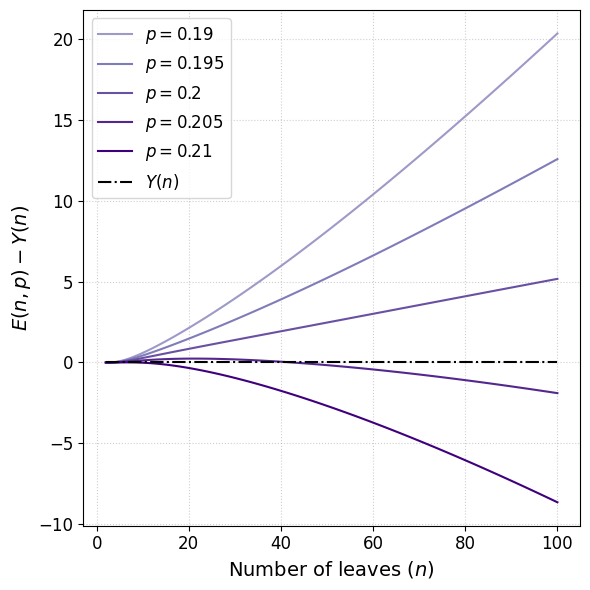

In [6]:
# Comparing the p=0.2 case to Yule
plt.figure(figsize=(6, 6))
s = [0.19, 0.195, 0.2, 0.205, 0.21]

max_color = 1
min_color = 0.5

for si in s:
    diff = [sackin_mean_const_p(n, si) - sackin_yule(n) for n in N]
    plt.plot(N, diff, label=f"$p={si}$", alpha=1, color=cm.Purples((max_color - min_color) / (s[-1] - s[0]) * (si - s[0]) + min_color))

plt.plot(N, [0] * len(N), color='black', linestyle='-.', label="$Y(n)$")
plt.xlabel("Number of leaves ($n$)", fontsize=14)
plt.ylabel("$E(n,p) - Y(n)$", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc="upper left")

# Grid and layout
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

plt.savefig("./plots/sackin_biased_speciation_constant_p_0.2_difference_yule.png", dpi=300)
plt.show()

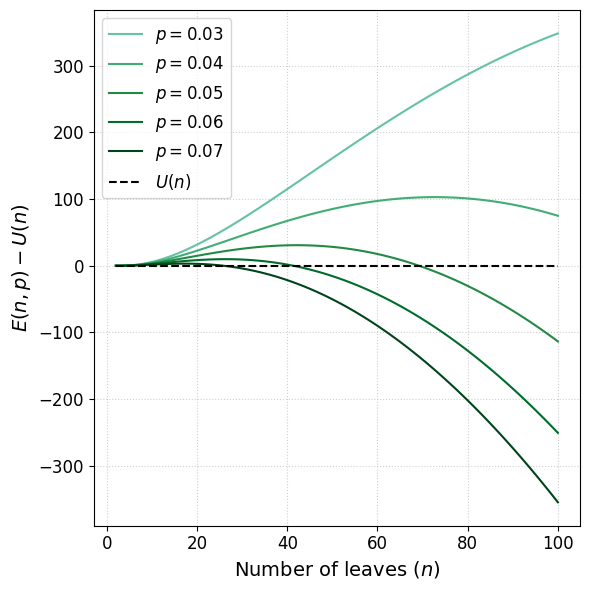

In [7]:
# Do same for Uniform model
plt.figure(figsize=(6, 6))

s = [0.03, 0.04, 0.05, 0.06, 0.07]

for s1 in s:
    diff = [sackin_mean_const_p(n, s1) - sackin_uniform(n) for n in N]
    plt.plot(N, diff, label=f"$p={s1}$", alpha=1, color=cm.BuGn((max_color - min_color) / (s[-1] - s[0]) * (s1 - s[0]) + min_color))
plt.plot(N, [0] * len(N), color='black', linestyle='--', label="$U(n)$")
plt.xlabel("Number of leaves ($n$)", fontsize=14)
plt.ylabel("$E(n,p) - U(n)$", fontsize=14)
plt.legend(fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.savefig("./plots/sackin_biased_speciation_constant_p_0.02_difference_uniform.png", dpi=300)
plt.show()

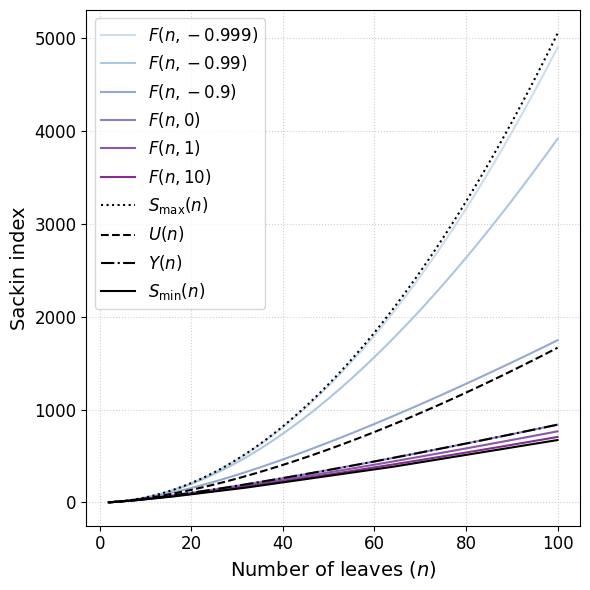

In [30]:
alpha = [0.001, 0.01, 0.1, 1, 2, 11]
plt.figure(figsize=(6, 6))

N = range(2, 100 + 1)
min_color = 0.2
max_color = 0.8
colors = cm.BuPu(np.linspace(min_color, max_color, len(alpha)))

for a, color in zip(alpha, colors):
    means = [sackin_mean_beta(n, a, a) for n in N]
    plt.plot(N, means, label=f"$F(n,{a - 1})$", alpha=1, color=color, lw=1.5)


# Add reference models
plt.plot(N, [max_sackin(n) for n in N], 
         label="$S_{\\max} (n)$", linestyle=':', color='black', alpha=1, linewidth=1.5)
plt.plot(N, [sackin_uniform(n) for n in N], 
         label="$U(n)$", linestyle='--', color='black', alpha=1, linewidth=1.5)
plt.plot(N, [sackin_yule(n) for n in N], 
         label="$Y(n)$", linestyle='-.', color='black', alpha=1, linewidth=1.5)
plt.plot(N, [min_sackin(n) for n in N], 
         label="$S_{\\min}(n)$", linestyle='-', color='black', alpha=1, linewidth=1.5)

# Labels and title
plt.xlabel("Number of leaves ($n$)", fontsize=14)
plt.ylabel("Sackin index", fontsize=14)
# plt.title(r"Mean Sackin index under biased speciation model with split distribution $\lambda \sim p$", fontsize=16)

# Fontsize of axis ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


# Legend only for reference lines
plt.legend(fontsize=12, loc="upper left")

# Grid and layout
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

# Save and show
plt.savefig("./plots/sackin_biased_speciation_blum_francois_beta_splitting.png", dpi=300)
plt.show()

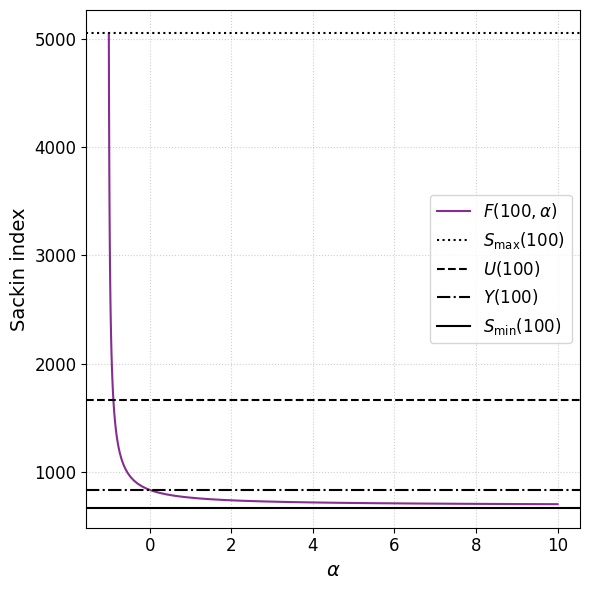

In [32]:
# Do same with beta(alpha + 1, alpha + 1) model
plt.figure(figsize=(6, 6))
a = np.logspace(-5, 1, 100, base=10)
a = np.concatenate((a, np.array([11])))

n = 100
plt.plot(a - 1, [sackin_mean_beta(n, ai, ai) for ai in a], color = cm.BuPu(np.ones(1)*0.8), label="$F(100, \\alpha)$", lw=1.5)

# Add horizontal lines for reference models
plt.axhline(max_sackin(n), color='black', linestyle=':', label="$S_{\\max} (100)$", lw = 1.5)
plt.axhline(sackin_uniform(n), color='black', linestyle='--', label="$U(100)$", lw = 1.5)
plt.axhline(sackin_yule(n), color='black', linestyle='-.', label="$Y(100)$", lw = 1.5)
plt.axhline(min_sackin(n), color='black', linestyle='-', label="$S_{\\min}(100)$", lw = 1.5)




plt.xlabel("$\\alpha$", fontsize=14)
plt.ylabel("Sackin index", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig("./plots/sackin_biased_speciation_blum_francois_beta_splitting_fixed_n.png", dpi=300)
plt.show()

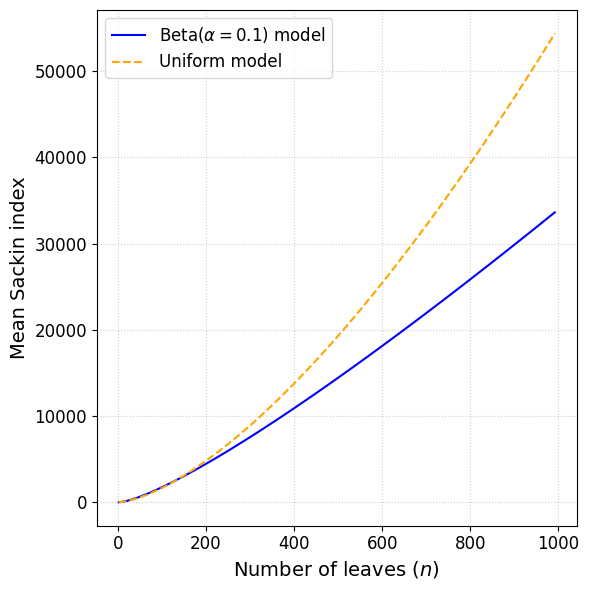

In [9]:
# Compare to Uniform model

plt.figure(figsize=(6, 6))
alpha = 0.1

N = range(2, 1000 + 1, 10)

plt.plot(N, [sackin_mean_beta(n, alpha, alpha) for n in N], label=f"Beta($\\alpha={alpha}$) model", linestyle='-', alpha = 1, color='blue')
plt.plot(N, [sackin_uniform(n) for n in N], label="Uniform model", linestyle='--', alpha = 1, color='orange')
plt.xlabel("Number of leaves ($n$)", fontsize=14)
plt.ylabel("Mean Sackin index", fontsize=14)
# plt.title("Comparison of Beta($\\alpha=0.5$) model to Uniform model", fontsize=16)
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
# plt.savefig("./plots/sackin_biased_speciation_blum_francois_beta_vs_uniform.png", dpi=300)
plt.show()

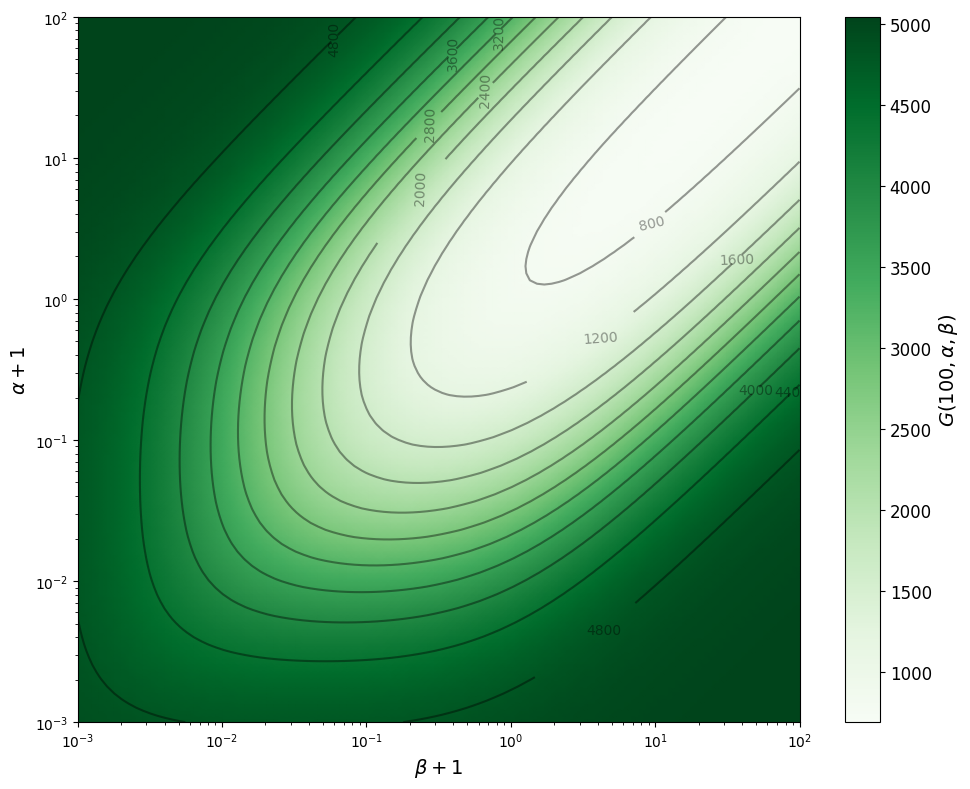

In [14]:
a = np.logspace(-3, 2, 100)
b = a
n = 100

mean_sackin = np.zeros((len(a), len(b)))
for i, ai in enumerate(a):
    for j, bi in enumerate(b):
        mean_sackin[i, j] = sackin_mean_beta(n, ai, bi)

plt.figure(figsize=(10, 8))
mesh = plt.pcolormesh(b, a, mean_sackin, shading='gouraud', cmap='Greens')

# Add contour lines (on top)
contours = plt.contour(b, a, mean_sackin, colors='k', alpha=0.4, levels=10)

plt.clabel(contours, inline=True, fontsize=10, fmt='%.0f')  # label lines with values

# Colorbar
cbar = plt.colorbar(mesh)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('$G(100, \\alpha, \\beta)$', fontsize=14)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta + 1$', fontsize=14)
plt.ylabel(r'$\alpha + 1$', fontsize=14)

plt.tight_layout()
plt.savefig("./plots/sackin_biased_speciation_sainudiin_veber_fixed_n.png", dpi=300)
plt.show()


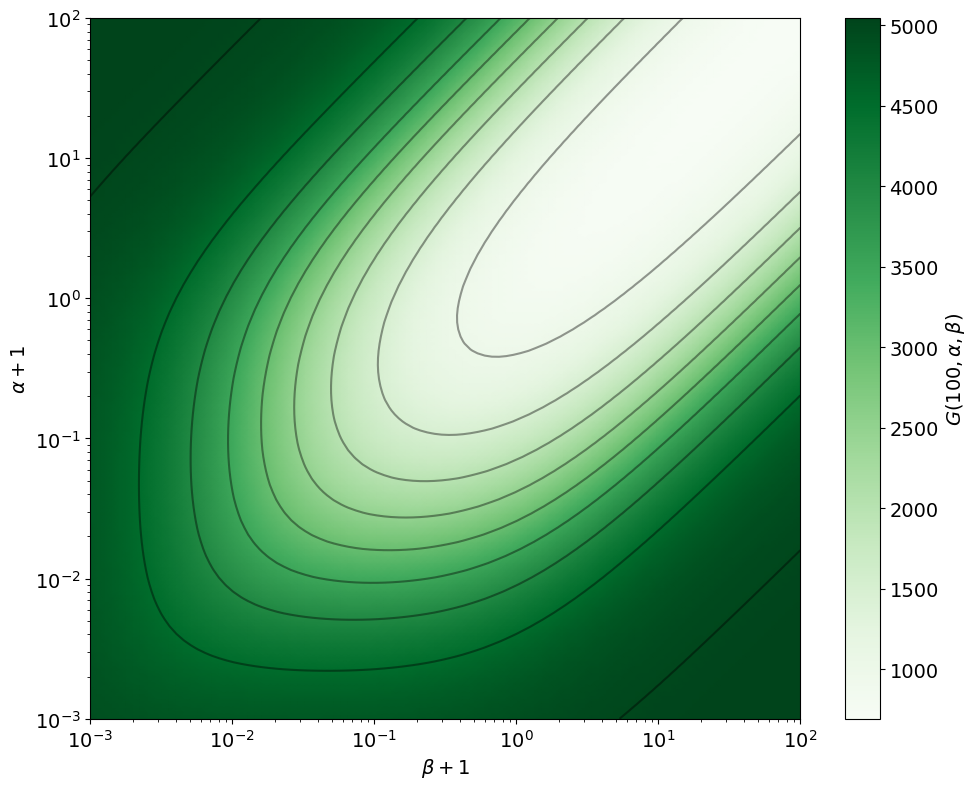

In [29]:
plt.figure(figsize=(10, 8))
mesh = plt.pcolormesh(b, a, mean_sackin, shading='gouraud', cmap='Greens')

# Add contour lines (on top)
contours = plt.contour(b, a, mean_sackin, colors='k', alpha=0.4, levels=8)

# plt.clabel(contours, inline=True, fontsize=10, fmt='%.0f')  # label lines with values

# Colorbar
cbar = plt.colorbar(mesh)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('$G(100, \\alpha, \\beta)$', fontsize=14)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta + 1$', fontsize=14)
plt.ylabel(r'$\alpha + 1$', fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.savefig("./plots/sackin_biased_speciation_sainudiin_veber_fixed_n.png", dpi=300)
plt.show()

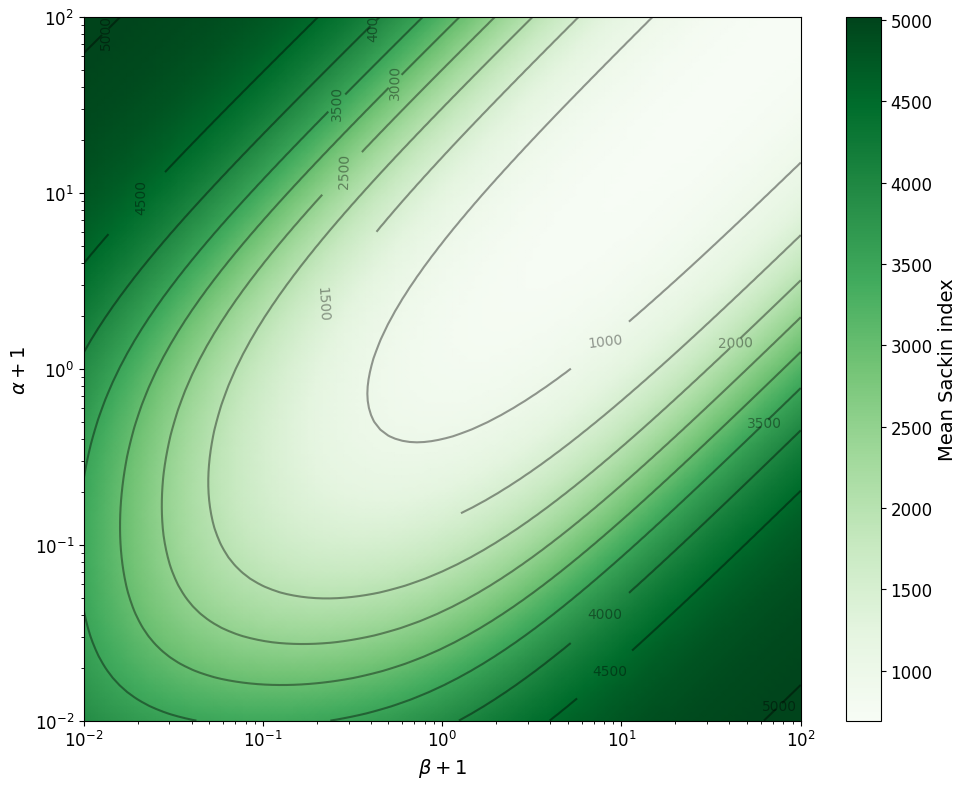

In [101]:
# Just the plot part
plt.figure(figsize=(10, 8))
mesh = plt.pcolormesh(b, a, mean_sackin, shading='gouraud', cmap='Greens')

# Add contour lines (on top)
contours = plt.contour(b, a, mean_sackin, colors='k', alpha=0.4, levels=8)

plt.clabel(contours, inline=True, fontsize=10, fmt='%.0f')  # label lines with values

# Colorbar
cbar = plt.colorbar(mesh)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Mean Sackin index', fontsize=14)

plt.xscale('log')
plt.yscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel(r'$\beta + 1$', fontsize=14)
plt.ylabel(r'$\alpha + 1$', fontsize=14)

plt.tight_layout()
plt.savefig("./plots/sackin_biased_speciation_sainudiin_veber_fixed_n.png", dpi=300)
plt.show()


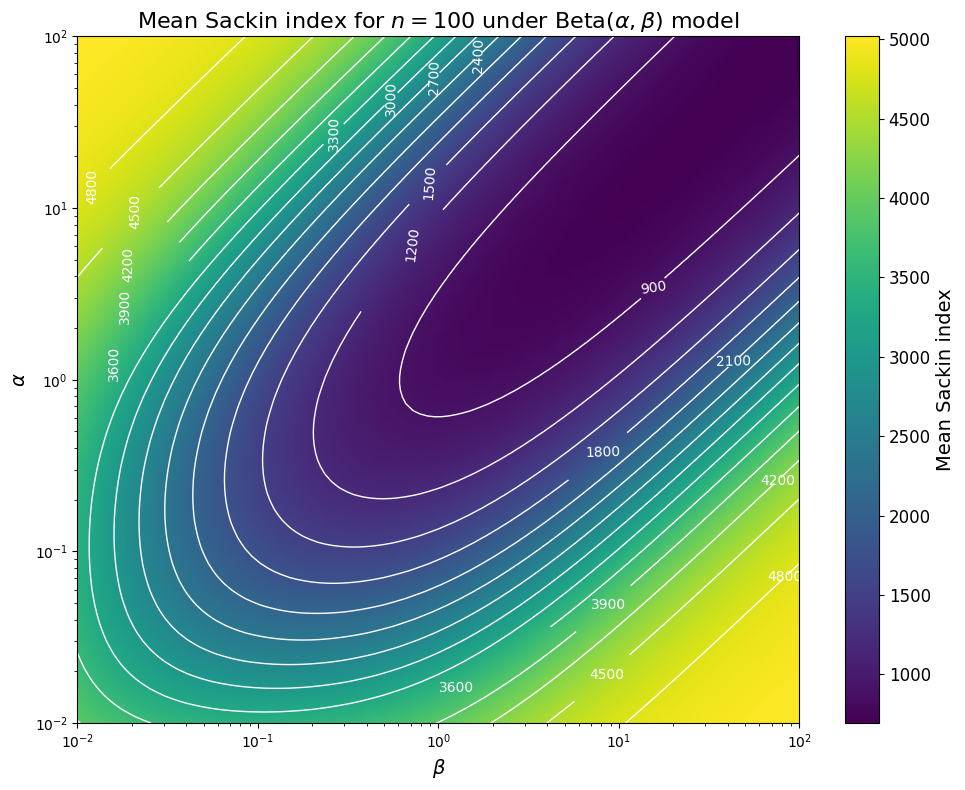

In [114]:
plt.figure(figsize=(10, 8))
mesh = plt.pcolormesh(b, a, mean_sackin, shading='gouraud', cmap='viridis')

# Add contour lines (on top)
contours = plt.contour(b, a, mean_sackin, 
                       colors='white', linewidths=1,
                       levels=15)  # 10 contour levels automatically chosen
plt.clabel(contours, inline=True, fontsize=10, fmt='%.0f')  # label lines with values
# Colorbar
cbar = plt.colorbar(mesh)
cbar.ax.tick_params(labelsize=12)
cbar.set_label('Mean Sackin index', fontsize=14)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\beta$', fontsize=14)
plt.ylabel(r'$\alpha$', fontsize=14)
plt.title(rf'Mean Sackin index for $n={n}$ under Beta($\alpha, \beta$) model', fontsize=16)

plt.tight_layout()
plt.show()


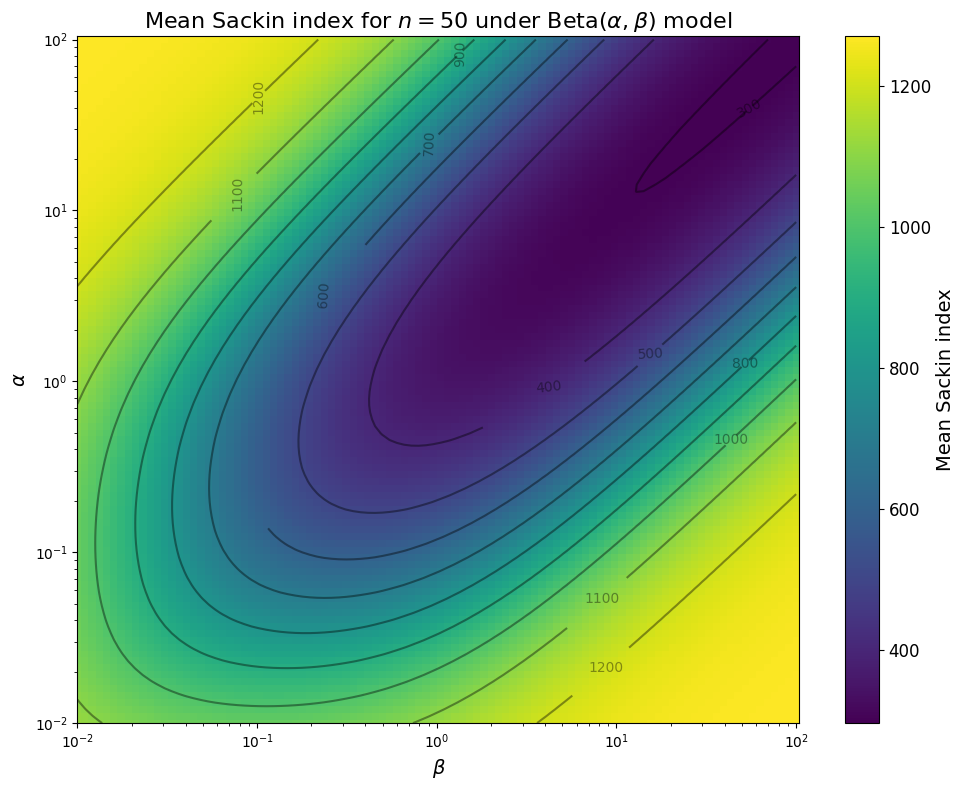

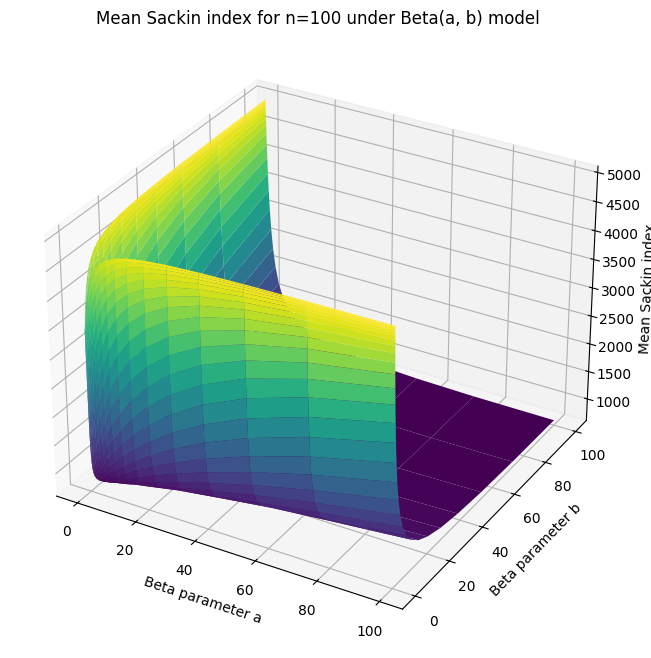

In [78]:
# Plot mean_sackin as a function of (a,b) in a 3D surface plot

from mpl_toolkits.mplot3d import Axes3D

plt.figure(figsize=(12, 8))
ax = plt.axes(projection='3d')
A, B = np.meshgrid(a, b)
ax.plot_surface(A, B, mean_sackin.T, cmap='viridis')
ax.set_xlabel('Beta parameter a')
ax.set_ylabel('Beta parameter b')
ax.set_zlabel('Mean Sackin index')
plt.title(f'Mean Sackin index for n={n} under Beta(a, b) model')
plt.show()

# Calculation time

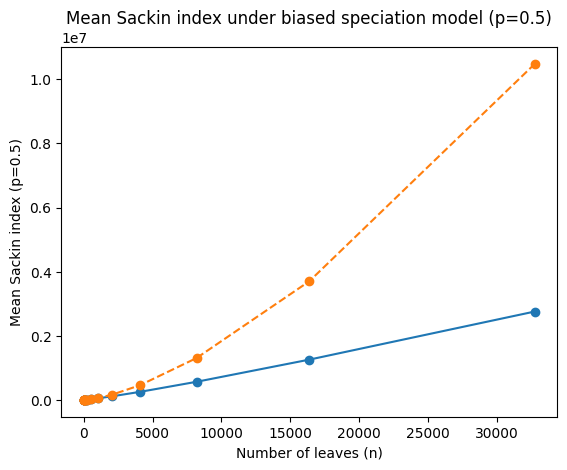

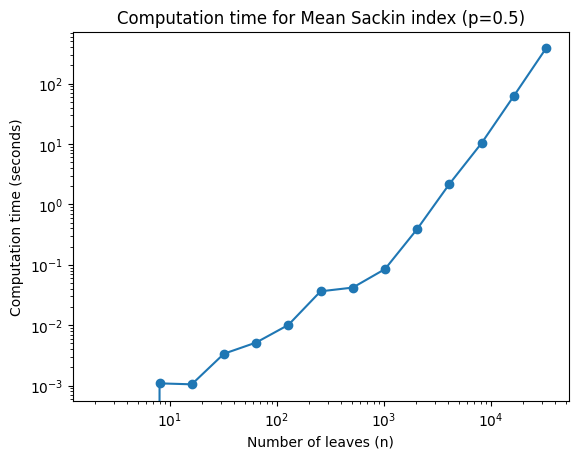

In [ ]:
# Time calculating the constant p model for p=0.5 and varying n

import time

n_values = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]
mean = []
p = 0.02
times = []
for n in n_values:
    start_time = time.time()
    mean.append(sackin_mean_const_p(n, p))
    end_time = time.time()
    times.append(end_time - start_time)

plt.plot(n_values, mean, marker='o')
plt.plot(n_values, [sackin_uniform(n) for n in n_values], marker='o', linestyle='--', label='Uniform model')
plt.xlabel('Number of leaves (n)')
plt.ylabel('Mean Sackin index (p=0.5)')
plt.title('Mean Sackin index under biased speciation model (p=0.5)')

plt.show()

plt.plot(n_values, times, marker='o')
plt.xlabel('Number of leaves (n)')
plt.ylabel('Computation time (seconds)')
plt.title('Computation time for Mean Sackin index (p=0.5)')
plt.yscale('log')
plt.xscale('log')
plt.show()

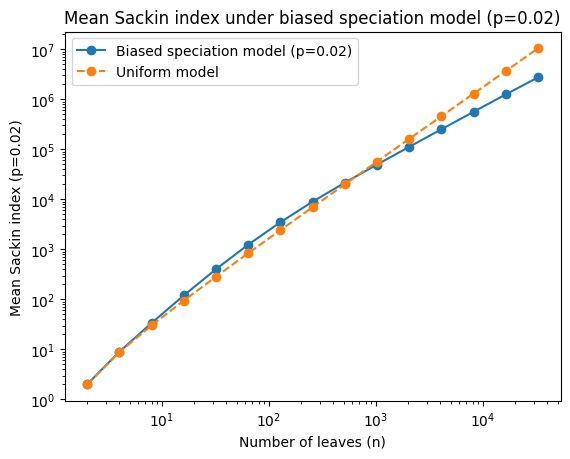

In [8]:
plt.plot(n_values, mean, marker='o', label='Biased speciation model (p=0.02)')
plt.plot(n_values, [sackin_uniform(n) for n in n_values], marker='o', linestyle='--', label='Uniform model')
plt.xlabel('Number of leaves (n)')
plt.ylabel('Mean Sackin index (p=0.02)')
plt.title('Mean Sackin index under biased speciation model (p=0.02)')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.show()


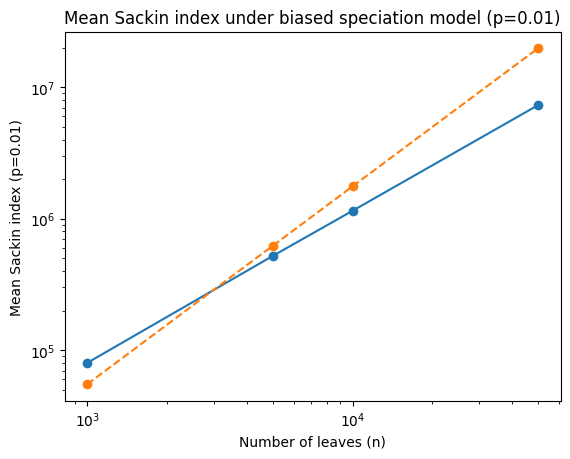

In [10]:
# Time calculating the constant p model for p=0.5 and varying n

n_values = [1000, 5000, 10000, 50000]
mean2 = []
p = 0.01
for n in n_values:
    mean2.append(sackin_mean_const_p(n, p))

plt.plot(n_values, mean2, marker='o', label=f'Biased speciation model (p={p})')
plt.plot(n_values, [sackin_uniform(n) for n in n_values], marker='o', linestyle='--', label='Uniform model')
plt.xlabel('Number of leaves (n)')
plt.ylabel(f'Mean Sackin index (p={p})')
plt.title(f'Mean Sackin index under biased speciation model (p={p})')
plt.xscale('log')
plt.yscale('log')

plt.show()


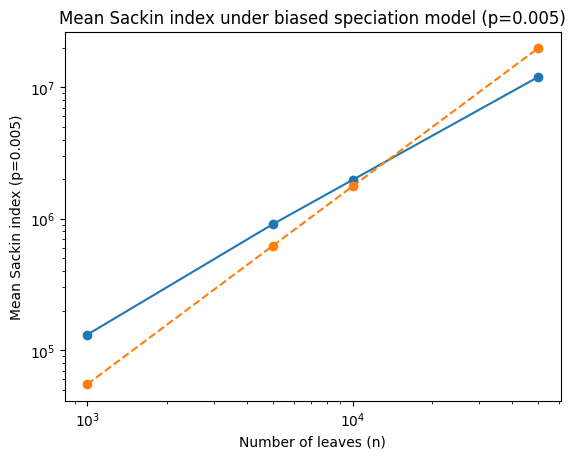

In [12]:
p = 0.005
mean3 = []
for n in n_values:
    mean3.append(sackin_mean_const_p(n, p))

plt.plot(n_values, mean3, marker='o', label=f'Biased speciation model (p={p})')
plt.plot(n_values, [sackin_uniform(n) for n in n_values], marker='o', linestyle='--', label='Uniform model')
plt.xlabel('Number of leaves (n)')
plt.ylabel(f'Mean Sackin index (p={p})')
plt.title(f'Mean Sackin index under biased speciation model (p={p})')
plt.xscale('log')
plt.yscale('log')

plt.show()

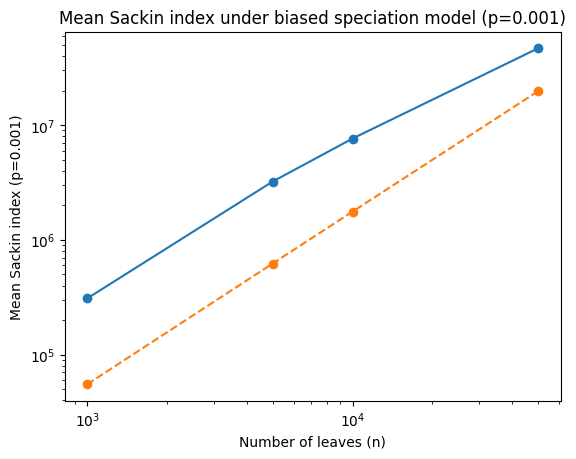

In [13]:
p = 0.001
mean4 = []
for n in n_values:
    mean4.append(sackin_mean_const_p(n, p))

plt.plot(n_values, mean4, marker='o', label=f'Biased speciation model (p={p})')
plt.plot(n_values, [sackin_uniform(n) for n in n_values], marker='o', linestyle='--', label='Uniform model')
plt.xlabel('Number of leaves (n)')
plt.ylabel(f'Mean Sackin index (p={p})')
plt.title(f'Mean Sackin index under biased speciation model (p={p})')
plt.xscale('log')
plt.yscale('log')

plt.show()

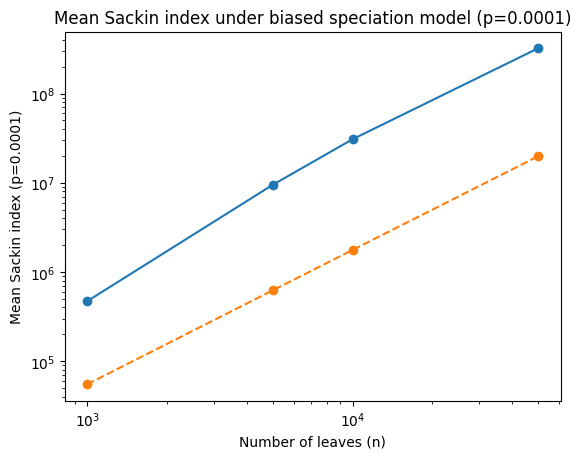

In [14]:
p = 0.0001
mean5 = []
for n in n_values:
    mean5.append(sackin_mean_const_p(n, p))

plt.plot(n_values, mean5, marker='o', label=f'Biased speciation model (p={p})')
plt.plot(n_values, [sackin_uniform(n) for n in n_values], marker='o', linestyle='--', label='Uniform model')
plt.xlabel('Number of leaves (n)')
plt.ylabel(f'Mean Sackin index (p={p})')
plt.title(f'Mean Sackin index under biased speciation model (p={p})')
plt.xscale('log')
plt.yscale('log')

plt.show()